Logistic Regression

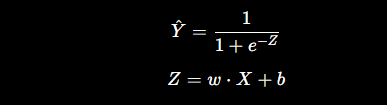

Y_hat --> predicted value

X --> Input Variable

w --> weight

b --> bias

**Gradient Descent:**

Gradient Descent is an optimization algorithm used for minimizing the loss function in various machine learning algorithms. It is used for updating the parameters of the learning model.

w  =  w - α*dw

b  =  b - α*db

**Learning Rate:**

Learning rate is a tuning parameter in an optimization algorithm that determines the step size at each iteration while moving toward a minimum of a loss function.

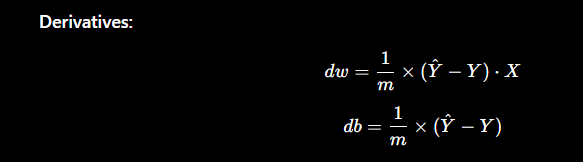

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [3]:
class Logistic_Regression():

  # declaring learning rate & number of iterations (Hyperparametes)
    def __init__(self , learning_rate , no_of_iterations):
        self.learning_rate = learning_rate
        self.no_of_iterations = no_of_iterations


  # fit function to train the model with dataset
    def fit(self , X ,Y):
          # number of data points in the dataset (number of rows)  -->  m
          # number of input features in the dataset (number of columns)  --> n
        self.m , self.n = X.shape


       #initiating weight & bias value
        self.w = np.zeros(self.n)
        self.b = 0
        self.X = X
        self.Y = Y

        # implementing Gradient Descent for Optimization
        for i in range(self.no_of_iterations):
            self.update_weights()


    def update_weights(self):

        # Y_hat formula (sigmoid function)
        Y_hat = 1 / (1 + np.exp(-(self.X.dot(self.w) + self.b)))

       # derivaties
        dw = (1/self.m)*np.dot(self.X.T , (Y_hat - self.Y))
        db = (1/self.m)*(np.sum(Y_hat - self.Y))

       
      # updating the weights & bias using gradient descent
        self.w = self.w - self.learning_rate*dw
        self.b = self.b -self.learning_rate*db
    

     # Sigmoid Equation & Decision Boundary
    def predict(self , X):

        Y_prediction = 1 / (1 + np.exp( - (X.dot(self.w) + self.b ) )) 
        Y_prediction = np.where(Y_prediction> 0.5 , 1,0)
        return Y_prediction

In [4]:
df = pd.read_csv('E:/ML/diabetes.csv')

In [5]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [7]:
df.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


In [8]:
# separating the data and labels
features = df.drop(columns = 'Outcome', axis=1)
target = df['Outcome']

In [9]:
scaler = StandardScaler()
scaler.fit(features)
standardized_data = scaler.transform(features)

In [10]:
print(standardized_data)

[[ 0.63994726  0.84832379  0.14964075 ...  0.20401277  0.46849198
   1.4259954 ]
 [-0.84488505 -1.12339636 -0.16054575 ... -0.68442195 -0.36506078
  -0.19067191]
 [ 1.23388019  1.94372388 -0.26394125 ... -1.10325546  0.60439732
  -0.10558415]
 ...
 [ 0.3429808   0.00330087  0.14964075 ... -0.73518964 -0.68519336
  -0.27575966]
 [-0.84488505  0.1597866  -0.47073225 ... -0.24020459 -0.37110101
   1.17073215]
 [-0.84488505 -0.8730192   0.04624525 ... -0.20212881 -0.47378505
  -0.87137393]]


In [11]:
features = standardized_data
target = df['Outcome']

In [12]:
X_train, X_test, Y_train, Y_test = train_test_split(features,target, test_size = 0.2, random_state=2)

In [13]:
classifier = Logistic_Regression(learning_rate=0.01, no_of_iterations=1000)

In [14]:
#training the support vector Machine Classifier
classifier.fit(X_train, Y_train)

In [16]:
# accuracy score on the training data
X_train_prediction = classifier.predict(X_train)
training_data_accuracy = accuracy_score( Y_train, X_train_prediction)
print('Accuracy score of the training data : ', training_data_accuracy)

Accuracy score of the training data :  0.7768729641693811


In [18]:
#accuracy score on the testing data
X_test_prediction = classifier.predict(X_test)
testing_data_accuracy = accuracy_score(Y_test , X_test_prediction)
print('Accuray score of the testing data :' , testing_data_accuracy)

Accuray score of the testing data : 0.7662337662337663


In [19]:
input_data = (5,166,72,19,175,25.8,0.587,51)

# changing the input_data to numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the array as we are predicting for one instance
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

# standardize the input data
std_data = scaler.transform(input_data_reshaped)
print(std_data)

prediction = classifier.predict(std_data)
print(prediction)

if (prediction[0] == 0):
  print('The person is not diabetic')
else:
  print('The person is diabetic')

[[ 0.3429808   1.41167241  0.14964075 -0.09637905  0.82661621 -0.78595734
   0.34768723  1.51108316]]
[1]
The person is diabetic


c:\Users\ataur\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
